<br><br><br>
# Pytorch Embeddings Module
<br>

## Basic Notebook
<br>

This notebook is meant to illustrate the basic usage of the **pytorch_embeddings** python module. 

First, let's import the modules we need. 



In [1]:
import json
import torch
import matplotlib.pyplot as plt
# now we import is our module
import pytorch_embeddings

<br>
In the cell below we create three embeddings. 
<br><br>

*embedding_A* is an instance of the usual native **torch.nn.Embedding** module. 

*embedding_B* is the same, it's just being created through the **pytorch_embeddings** module. 

*embedding_C* is an instance of the **FrobeniusEmbedding** module. 
<br><br>
By default, Frobenius embeddings work only with the following embedding dimensions: **8, 16, 32, 64, 128, 256**. <br>
Moreover, only **torch.float32** and **torch.float16** datatypes are supported. <br><br>

In [2]:
batch_size = 1024
num_embeddings = 10240
embedding_dim = 256

embedding_A = torch.nn.Embedding(num_embeddings, embedding_dim, device='cuda')
torch.nn.init.normal_(embedding_A.weight, 0.0, 1.0)

embedding_B = pytorch_embeddings.NativeEmbedding(num_embeddings, embedding_dim)
torch.nn.init.normal_(embedding_B.weight, 0.0, 1.0)

embedding_C = pytorch_embeddings.FrobeniusEmbedding(num_embeddings, embedding_dim)
pytorch_embeddings.frobenius_normal_(embedding_C, 0.0, 1.0)

<br>
Let's see the shapes and types of these embeddings. Notice the default device the embeddings are created on. 
<br><br>

In [3]:
for embedding in (embedding_A, embedding_B, embedding_C):
    print(embedding.weight.shape, embedding.weight.dtype, embedding.weight.device)

torch.Size([10240, 256]) torch.float32 cuda:0
torch.Size([10240, 256]) torch.float32 cuda:0
torch.Size([5504]) torch.float32 cuda:0


<br><br>
Frobenius embeddings were meant to be used only on the **GPU**. <br>
<br>
Let's see what information do we get from printing these embeddings to the console. 
<br><br>

In [4]:
print(embedding_A)
print(embedding_B)
print(embedding_C)

Embedding(10240, 256)
Embedding(embedding_type=native, num_embeddings=10240, embedding_dim=256, precision=fp32, size=10.0 MB)
Embedding(embedding_type=frobenius, num_embeddings=10240, embedding_dim=256, precision=fp32, size=0.005249 MB, frobenius_rank=8, frobenius_blocks=2)


<br>

Notice the *frobenius_rank* and *frobenius_blocks* parameters of the Frobenius embedding. <br>
These parameters influence the upper bound on the capacity of Frobenius embeddings. <br>
Moreover, they also influence its size, latency and throughput. <br>
<br>
By default, a heuristic automatically selects these parameters, so we won't have to worry about that here. 
<br>
Now, let's look at the histograms of the outputs of these layers. 
<br><br>

In [5]:
def show_histogram(tensor, title=''):
    bins = 60
    hist = torch.histc(tensor.cpu(), bins=bins, min=-2, max=2)
    plt.bar(range(bins), hist, align='center')
    plt.xlabel('values' + title)
    plt.ylabel('frequency of values')
    plt.show()

In [6]:
index = torch.randint(0,num_embeddings,(batch_size,),device='cuda')
output_A = embedding_A(index)
output_B = embedding_B(index)
output_C = embedding_C(index)

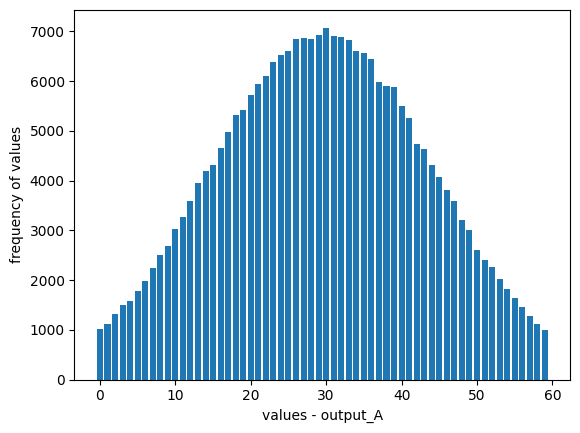

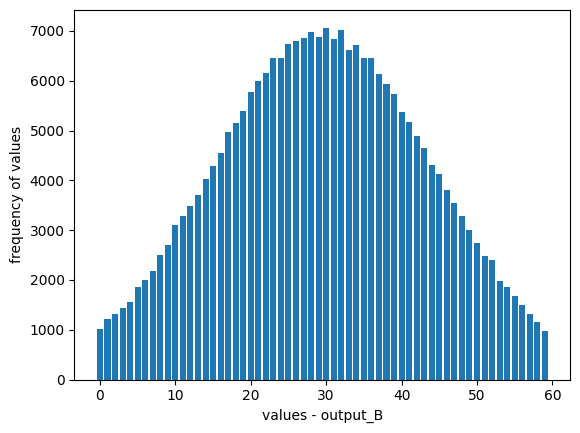

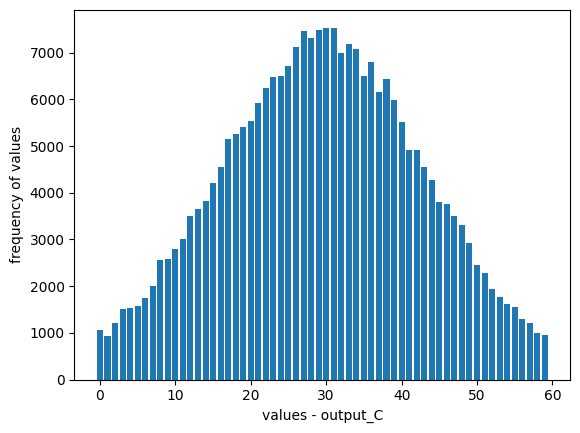

In [7]:
show_histogram(output_A, ' - output_A')
show_histogram(output_B, ' - output_B')
show_histogram(output_C, ' - output_C')

<br><br>
Above we can see the three histograms for the outputs of *embedding_A*, *embedding_B* and *embedding_C*, respectively. <br>
Notice, that *output_C*, i.e. the output of the Frobenius embedding only **approximates** a normal distribution. <br><br>
This is to be expected, as Frobenius embeddings were designed to capture the underlying structure of the embedding tables. <br>
The worst type of data for them is random data, as it does not have the kind of structure to be captured, that would allow for large compression ratios. <br>
On the other hand, matrices occuring in big data applications can be reasonably expected to have the structure Frobenius embeddings can capture. <br>
<br>
Perhaps there is merit in seeing some numeric values we could compare. 
<br><br>

In [8]:
def print_stats(name, tensor):
    mean = tensor.mean().item()
    std = tensor.std().item()
    absmax = tensor.abs().max().item()
    absmin = tensor.abs().min().item()
    range_max = tensor.max().item()
    range_min = tensor.min().item()
    d = {
            'name' : name, 
            'mean' : mean, 
            'std' : std, 
            'range_max' : range_max, 
            'range_min' : range_min, 
            'absmax' : absmax, 
            'absmin' : absmin
    }
    d = json.dumps(d, indent=4)
    print(d)

In [9]:
print_stats('output_A', output_A)
print_stats('output_B', output_B)
print_stats('output_C', output_C)

{
    "name": "output_A",
    "mean": -0.0027453992515802383,
    "std": 0.9991097450256348,
    "range_max": 4.369663715362549,
    "range_min": -4.712396144866943,
    "absmax": 4.712396144866943,
    "absmin": 1.1715852679117233e-06
}
{
    "name": "output_B",
    "mean": 0.0021457942202687263,
    "std": 1.0026918649673462,
    "range_max": 4.328327655792236,
    "range_min": -4.5429158210754395,
    "absmax": 4.5429158210754395,
    "absmin": 6.735495844623074e-06
}
{
    "name": "output_C",
    "mean": -0.007809734903275967,
    "std": 0.979233980178833,
    "range_max": 4.088677883148193,
    "range_min": -4.235252380371094,
    "absmax": 4.235252380371094,
    "absmin": 3.688322749439976e-07
}


<br><br>
The manual replacement of **torch.nn.Embedding** modules with **pytorch_embeddings.FrobeniusEmbedding** and the appropriate initializers can be cumbersome, especially in large models. <br>
Fortunately, the **decomposed_embeddings** context manager in the **pytorch_embeddings** module makes this task easier for us. <br><br>

In [10]:
from pytorch_embeddings import decomposed_embeddings

In [11]:
with decomposed_embeddings(embedding_type=['frobenius']):
    embedding_A = torch.nn.Embedding(num_embeddings, embedding_dim, device='cuda')
    torch.nn.init.normal_(embedding_A.weight, 0.0, 1.0)

print(embedding_A)

Embedding(embedding_type=frobenius, num_embeddings=10240, embedding_dim=256, precision=fp32, size=0.005249 MB, frobenius_rank=8, frobenius_blocks=2)


<br><br>

We can even construct multiple embeddings with different configurations. <br><br>

In [12]:
with decomposed_embeddings(embedding_type=['frobenius','frobenius','native']):
    embedding_A = torch.nn.Embedding(num_embeddings, embedding_dim, device='cuda')
    embedding_B = torch.nn.Embedding(num_embeddings, embedding_dim, device='cuda')
    embedding_C = torch.nn.Embedding(num_embeddings, embedding_dim, device='cuda')
    torch.nn.init.normal_(embedding_A.weight, 0.0, 1.0)
    torch.nn.init.uniform_(embedding_B.weight, -1.0, 1.0)
    torch.nn.init.normal_(embedding_C.weight, 0.0, 1.0)

print(embedding_A)
print(embedding_B)
print(embedding_C)

Embedding(embedding_type=frobenius, num_embeddings=10240, embedding_dim=256, precision=fp32, size=0.005249 MB, frobenius_rank=8, frobenius_blocks=2)
Embedding(embedding_type=frobenius, num_embeddings=10240, embedding_dim=256, precision=fp32, size=0.005249 MB, frobenius_rank=8, frobenius_blocks=2)
Embedding(embedding_type=native, num_embeddings=10240, embedding_dim=256, precision=fp32, size=10.0 MB)


<br><br>
Notice from the above, that the order of the keywords in the list *embedding_type* corresponds to the order in which the embeddings are constructed within the context. <br>

Naturally, this mechanism will work even if we place it inside a model. 
<br><br>

In [13]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding_A = torch.nn.Embedding(num_embeddings, embedding_dim, device='cuda')
        self.embedding_B = torch.nn.Embedding(num_embeddings, embedding_dim, device='cuda')
        self.embedding_C = torch.nn.Embedding(num_embeddings, embedding_dim, device='cuda')
        torch.nn.init.normal_(embedding_A.weight, 0.0, 1.0)
        torch.nn.init.uniform_(embedding_B.weight, -1.0, 1.0)
        torch.nn.init.normal_(embedding_C.weight, 0.0, 1.0)

    def forward(self, index):
        output_A = self.embedding_A(index)
        output_B = self.embedding_B(index)
        output_AB = (output_A * output_B).view(1,-1)
        output_C = self.embedding_C(index)
        output_C = output_C.view(-1,1)
        output = output_AB @ output_C
        return output


with decomposed_embeddings(embedding_type=['frobenius','frobenius','native']):
    model = NeuralNetwork(num_embeddings, embedding_dim)


print(model)

NeuralNetwork(
  (embedding_A): Embedding(embedding_type=frobenius, num_embeddings=10240, embedding_dim=256, precision=fp32, size=0.005249 MB, frobenius_rank=8, frobenius_blocks=2)
  (embedding_B): Embedding(embedding_type=frobenius, num_embeddings=10240, embedding_dim=256, precision=fp32, size=0.005249 MB, frobenius_rank=8, frobenius_blocks=2)
  (embedding_C): Embedding(embedding_type=native, num_embeddings=10240, embedding_dim=256, precision=fp32, size=10.0 MB)
)


<br><br>

The **decomposed_embeddings** context manager accepts the following keywords: 

&nbsp;&nbsp;&nbsp;&nbsp;*embedding_type* : list of str, each of which is either **frobenius** or **native** <br>
&nbsp;&nbsp;&nbsp;&nbsp;*frobenius_rank* : list of int, one int for each Frobenius embedding <br>
&nbsp;&nbsp;&nbsp;&nbsp;*frobenius_blocks* : list of int, one int for each Frobenius embedding <br>
&nbsp;&nbsp;&nbsp;&nbsp;*silent* : bool. it can be used to suppress all the messages printed to the console by the module. default: **False** <br>
&nbsp;&nbsp;&nbsp;&nbsp;*onchip_memory* : bool. setting it to **True** will reduce the memory consumption of the forward pass, at the expense of latency. default: **True** <br>
&nbsp;&nbsp;&nbsp;&nbsp;*alternating_gradients* : bool. setting it to **True** will slow down convergence and also make it more stable. default: **False** <br>
<br><br>
This concludes this introductory notebook. The advanced notebook discusses the following features: 
- **heuristics**, 
- large **embedding_dim**, 
- usage on the **CPU**, 
- deployment into **Torchscript** format, 
- deployment into **TensorRT** format. 
<br><br>